# 06 - Phase 2 panel: origin, destination, and net migration

Phase 1 established that first-year enrolment in the fee states fell by roughly 5 to 7
percent **at the university location**. That outcome counts students where they enrol, so a
student who abandoned higher education and a student who crossed a state border look
identical in it.

This notebook builds the panel that can tell them apart, from Fachserie 11 Reihe 4.1 detailed
table 6, which gives first-years by study state **and** by the state where the university
entrance qualification was earned. It validates the extraction and describes what is there.
No estimation: power and pre-trends are notebook 07, the effect is notebook 08.

**Window: WS 2003/04 to WS 2007/08.** Five volumes, three pre-treatment periods and two post.
Shorter than phase 1's ten periods because the Fachserie is only machine-readable from
2003/04; earlier volumes exist as scans whose OCR cannot be trusted for numeric tables
(`DESIGN.md` 14.1). This is the main cost of the matrix route and it is stated rather than
hidden.

**The three outcomes** (`DESIGN.md` 14.3), for state `s` in winter semester `t`:

| name | definition | what it measures |
|---|---|---|
| `study_location` | row total of the matrix | phase 1's outcome, used here only to reconcile |
| `origin` | column total over study states | first-years **from** `s`, wherever they enrolled |
| `net_inflow` | `(study_location - unattributed) - origin` | the diversion outcome |

`net_inflow` counts German-HZB holders on both sides. Why, and the evidence for it, is
section 4 below.

In [1]:
import sys, glob, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "data" / "processed" / "panel.parquet").exists():
            return cand
    raise FileNotFoundError("panel.parquet not found. Run: py src/build_panel.py")

ROOT = find_root(); sys.path.insert(0, str(ROOT))
from src import fachserie as fsx

FIG = ROOT / "results" / "figures"; TAB = ROOT / "results" / "tables"
FIG.mkdir(parents=True, exist_ok=True); TAB.mkdir(parents=True, exist_ok=True)
RAW = ROOT / "data" / "raw" / "fachserie"

plt.rcParams["figure.figsize"] = (11, 5.5)
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3

# selected by semester, not by extension: the folder also holds the
# phase 3 volumes, and Destatis switched to .xlsx from WS 2013/14
VOLUMES = fsx.select_volumes(RAW, 2003, 2007)
if not VOLUMES:
    raise FileNotFoundError(f"no Fachserie volumes in {RAW}. See src/acquire.py.")

print(f"{len(VOLUMES)} volumes found:")
for v in VOLUMES:
    print(f"  {Path(v).name}  ->  winter semester {fsx.winter_semester_year(v)}")

5 volumes found:
  2110410047005.xls  ->  winter semester 2003
  2110410057005.xls  ->  winter semester 2004
  2110410067005.xls  ->  winter semester 2005
  2110410077005.xls  ->  winter semester 2006
  2110410087005.xls  ->  winter semester 2007


## 1. Validation gate

Three checks per volume, before anything is built on them (`DESIGN.md` 14.8). The parser
finds the first-year block by searching for its header rather than by a fixed row, because
the volumes differ in how many sheets they contain, so the first thing to confirm is that it
found the right block every time.

**Failure condition: any volume failing either reconciliation.** The panel is not built.

In [2]:
rows = []
for v in VOLUMES:
    flows, total, extra, year = fsx.read_matrix(v)
    r = fsx.validate(flows, total, extra)
    rows.append({"year": year, "Deutschland": int(r["germany_row"]),
                 "sum of states": int(r["sum_of_states"]),
                 "rows reconcile": r["rows_reconcile"],
                 "columns reconcile": r["columns_reconcile"],
                 "worst residual": r["worst_column_residual"],
                 "unattributed %": round(r["unattributed_share_pct"], 1)})
checks = pd.DataFrame(rows).sort_values("year")
print(checks.to_string(index=False))
checks.to_csv(TAB / "06_extraction_checks.csv", index=False)

ok = checks["rows reconcile"].all() and checks["columns reconcile"].all()
print(f"\nverdict: {'all volumes reconcile' if ok else 'FAILED - do not build the panel'}")
assert ok, "extraction failed validation; see the table above" 

 year  Deutschland  sum of states  rows reconcile  columns reconcile  worst residual  unattributed %
 2003       316656         316656            True               True             0.0            13.8
 2004       300793         300793            True               True             0.0            14.1
 2005       299839         299839            True               True             0.0            13.7
 2006       294946         294946            True               True             0.0            13.8
 2007       313540         313540            True               True             0.0            13.0

verdict: all volumes reconcile


### The strongest check: two publications of the same statistic

`study_location` from the Fachserie should equal `first_years_location` from GENESIS
21311-0014, the phase 1 source. They are different publications produced from the same
underlying student statistics, so agreement is expected, and disagreement would mean one of
them is not the measure this study thinks it is.

This is what lets phase 2 be read alongside phase 1 rather than as a separate study.

In [3]:
panel = fsx.build_panel(VOLUMES)

p1 = pd.read_parquet(ROOT / "data" / "processed" / "panel.parquet")
keep = ["state_code", "year", "first_years_location", "ever_treated", "intro_year",
        "treated", "east", "city_state"]
p1 = p1[[c for c in keep if c in p1.columns]]
d = panel.merge(p1, on=["state_code", "year"], how="left")

gap = (d["study_location"] - d["first_years_location"]).abs()
print(f"state-year cells compared : {len(d)}")
print(f"maximum absolute gap      : {gap.max():.0f}")
print(f"cells differing at all    : {(gap > 0).sum()}")
print("\nverdict:", "identical to the unit" if gap.max() == 0
      else "SOURCES DISAGREE - investigate before continuing")

d["fee"] = np.where(d.ever_treated == 1, "fee state", "never treated")
d["rel"] = np.where(d.ever_treated == 1, d.year - d.intro_year, np.nan)
print(f"\npanel: {d.shape[0]} rows, {d.state_code.nunique()} states, "
      f"{d.year.min()}-{d.year.max()}")
print(f"treated states in window: {int((d.groupby('state_code').ever_treated.first() == 1).sum())}")

state-year cells compared : 80
maximum absolute gap      : 0
cells differing at all    : 0

verdict: identical to the unit

panel: 80 rows, 16 states, 2003-2007
treated states in window: 7


## 2. What the matrix looks like

Before any outcome is derived, the raw structure. Most first-years study in the state where
they earned their qualification, and the size of that diagonal sets the scale for everything
else: if 70 percent never move, migration effects act on the remaining 30.

In [4]:
diag = []
for v in VOLUMES:
    flows, _, _, year = fsx.read_matrix(v)
    a = flows.to_numpy()
    diag.append({"year": year,
                 "first-years (German HZB)": int(a.sum()),
                 "studying in own state": int(a.diagonal().sum()),
                 "share %": round(100 * a.diagonal().sum() / a.sum(), 1)})
dg = pd.DataFrame(diag)
print(dg.to_string(index=False))
print("\nMigration acts on the complement of that share, so a fee effect on where")
print("students enrol is working on roughly three in ten of them.")

flows_last, _, _, yr_last = fsx.read_matrix(VOLUMES[-1])
top = (flows_last.stack().rename("n").reset_index()
       .query("origin != destination").nlargest(10, "n"))
print(f"\nlargest interstate flows, WS {yr_last}/{str(yr_last+1)[-2:]}:")
print(top.to_string(index=False))

 year  first-years (German HZB)  studying in own state  share %
 2003                    272911                 192457     70.5
 2004                    258455                 179849     69.6
 2005                    258783                 178624     69.0
 2006                    254282                 173987     68.4
 2007                    272916                 184137     67.5

Migration acts on the complement of that share, so a fee effect on where
students enrol is working on roughly three in ten of them.

largest interstate flows, WS 2007/08:
             origin         destination    n
  Baden-Württemberg              Bayern 4024
      Niedersachsen Nordrhein-Westfalen 2816
Nordrhein-Westfalen       Niedersachsen 2743
             Berlin         Brandenburg 2370
        Brandenburg              Berlin 2153
Nordrhein-Westfalen              Hessen 1783
             Bayern   Baden-Württemberg 1761
     Sachsen-Anhalt             Sachsen 1662
      Niedersachsen              Bremen

## 3. The two margins

`study_location` and `origin` for the same state answer different questions: how many
first-years enrolled here, and how many came from here. A state where the two move together
is not redistributing students; a state where they diverge is.

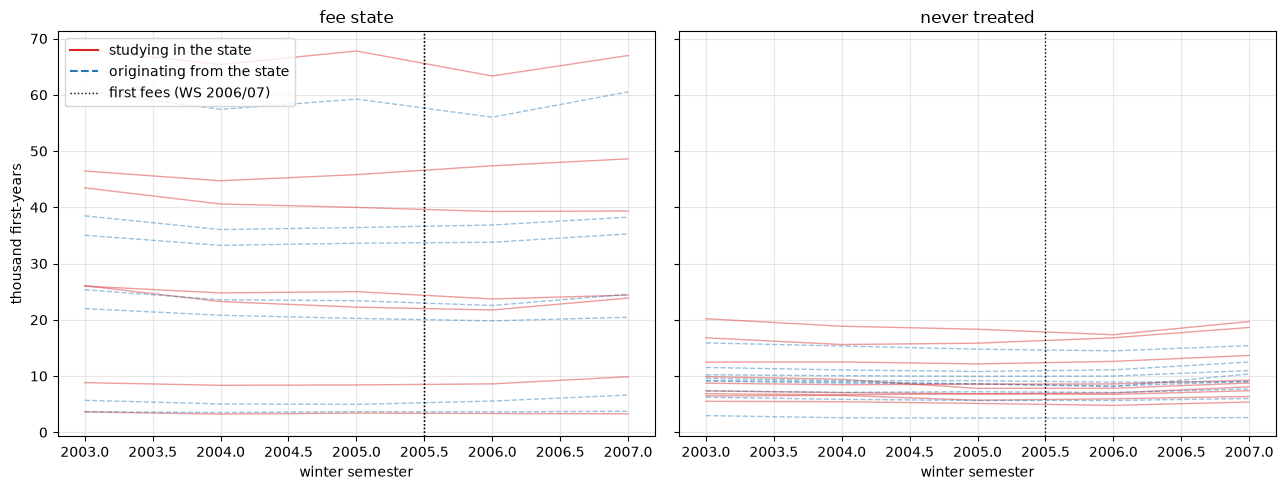

group totals (thousands):
        origin               study_location              
fee  fee state never treated      fee state never treated
year                                                     
2003     190.8          82.1          222.4          94.3
2004     179.6          78.9          210.3          90.5
2005     181.5          77.3          212.6          87.2
2006     178.2          76.1          207.4          87.6
2007     189.4          83.6          216.3          97.2


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, grp in zip(axes, ["fee state", "never treated"]):
    sub = d[d.fee == grp]
    for name, g in sub.groupby("state"):
        ax.plot(g.year, g.study_location / 1000, color="tab:red", alpha=0.45, lw=1)
        ax.plot(g.year, g.origin / 1000, color="tab:blue", alpha=0.45, lw=1, ls="--")
    ax.set_title(grp); ax.set_xlabel("winter semester")
    ax.axvline(2005.5, color="black", ls=":", lw=1)
axes[0].set_ylabel("thousand first-years")
axes[0].plot([], [], color="tab:red", label="studying in the state")
axes[0].plot([], [], color="tab:blue", ls="--", label="originating from the state")
axes[0].axvline(2005.5, color="black", ls=":", lw=1, label="first fees (WS 2006/07)")
axes[0].legend()
plt.tight_layout()
plt.savefig(FIG / "15_two_margins.png", dpi=130, bbox_inches="tight")
plt.show()

print("group totals (thousands):")
print(d.pivot_table(index="year", columns="fee",
                    values=["study_location", "origin"], aggfunc="sum")
       .div(1000).round(1).to_string())

## 4. Why `Ausland` and `ohne Angabe` are removed from both sides

The matrix carries two columns that cannot be attributed to a German state: students whose
qualification was earned abroad, and students whose origin is unrecorded. They are absent
from `origin` by construction, so the question is whether to leave them in
`study_location` when taking the difference.

`DESIGN.md` 14.3 decided to remove them, on the evidence reproduced here. The decision was
made before any treatment effect was estimated.

year                    2003  2004  2005  2006  2007  range          group
state                                                                     
Berlin                  22.6  25.1  25.5  25.5  25.5    2.9  never treated
Saarland                20.1  21.9  20.9  21.3  20.1    1.8      fee state
Bremen                  16.8  18.1  16.8  17.8  17.4    1.3  never treated
Baden-Württemberg       18.6  18.3  17.6  17.4  16.3    2.3      fee state
Brandenburg             17.2  16.7  18.7  17.4  15.1    3.6  never treated
Sachsen                 12.0  14.2  13.9  15.3  12.9    3.3  never treated
Hamburg                 11.6  15.7  16.7  12.9  12.3    5.1      fee state
Rheinland-Pfalz         14.1  14.0  13.1  13.1  12.0    2.1  never treated
Bayern                  12.9  12.9  12.8  12.6  11.6    1.3      fee state
Niedersachsen           13.9  14.5  13.6  12.6  11.6    2.9      fee state
Nordrhein-Westfalen     11.8  11.3  10.8  11.4  11.1    1.0      fee state
Hessen                  1

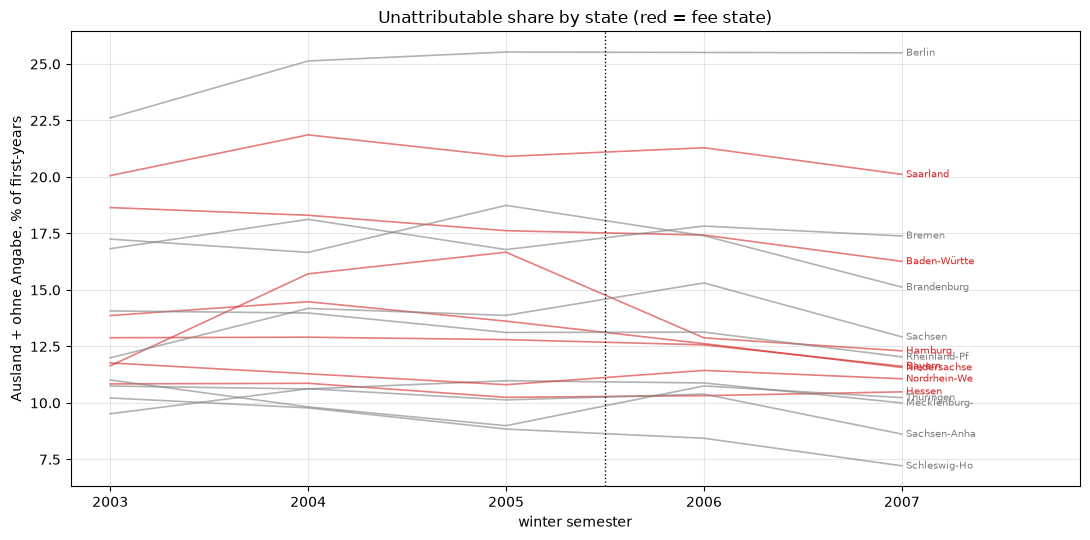


group means, %:
fee   fee state  never treated
year                          
2003      14.24          13.81
2004      15.06          14.33
2005      14.67          14.11
2006      14.08          14.40
2007      13.35          13.23


In [6]:
d["unattr_share"] = 100 * d.unattributed / d.study_location
wide = d.pivot_table(index="state", columns="year", values="unattr_share").round(1)
wide["range"] = (wide.max(axis=1) - wide.min(axis=1)).round(1)
wide["group"] = d.groupby("state").fee.first()
print(wide.sort_values(d.year.max(), ascending=False).to_string())
wide.to_csv(TAB / "06_unattributed_share.csv")

fig, ax = plt.subplots(figsize=(11, 5.5))
for name, g in d.groupby("state"):
    col = "tab:red" if g.fee.iloc[0] == "fee state" else "tab:grey"
    ax.plot(g.year, g.unattr_share, color=col, alpha=0.6, lw=1.2)
    ax.annotate(name[:12], (g.year.max(), g.unattr_share.iloc[-1]), fontsize=7,
                xytext=(3, 0), textcoords="offset points", va="center", color=col)
ax.axvline(2005.5, color="black", ls=":", lw=1)
ax.set_xlabel("winter semester"); ax.set_ylabel("Ausland + ohne Angabe, % of first-years")
ax.set_title("Unattributable share by state (red = fee state)")
ax.set_xlim(d.year.min() - 0.2, d.year.max() + 0.9)
plt.tight_layout()
plt.savefig(FIG / "16_unattributed_share.png", dpi=130, bbox_inches="tight")
plt.show()

print("\ngroup means, %:")
print(d.pivot_table(index="year", columns="fee", values="unattr_share").round(2).to_string())

## 5. The diversion outcome

`net_inflow` in levels is dominated by state size, so it is reported per 1 000 of the state's
own origin cohort. A positive value means the state hosts more German first-years than it
produces.

Both definitions are shown: the primary one on German-HZB holders, and the variant that
leaves the unattributable students in the destination term. The gap between them is the
contamination section 4 is about.

net inflow per 1 000 origin first-years, group means

primary (German HZB on both sides):
fee   fee state  never treated
year                          
2003       21.8            5.6
2004       15.9           21.4
2005       25.6           -1.3
2006       10.7            2.4
2007       -2.9           35.6

variant (unattributable left in the destination term):
fee   fee state  never treated
year                          
2003      188.8          173.9
2004      194.0          202.7
2005      201.0          172.9
2006      172.8          182.1
2007      147.1          206.9


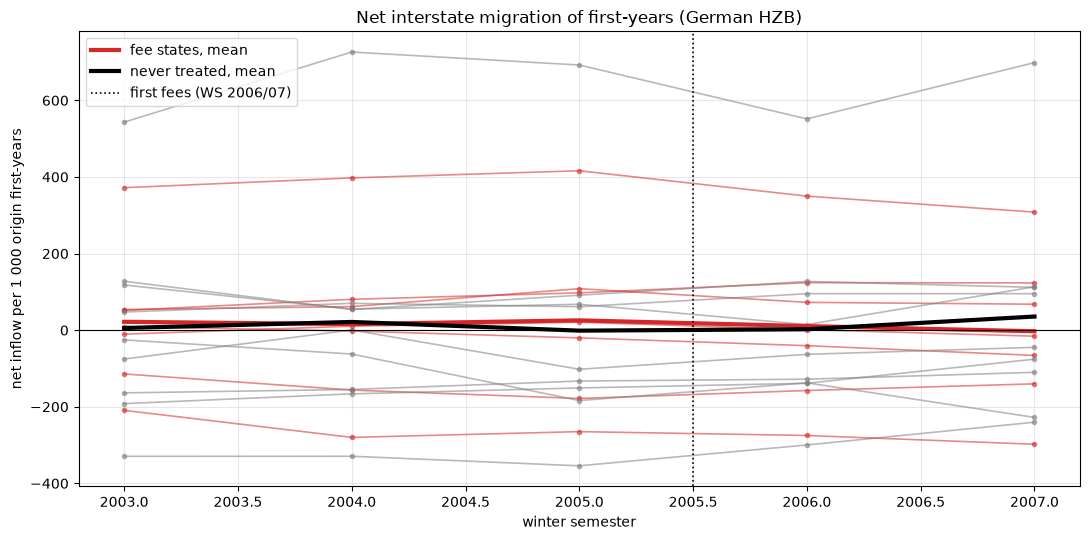


wrote C:\Users\wassi\Desktop\tuition-fees-causal-impact\results\tables\06_phase2_panel.csv


In [7]:
d["ni_per1k"] = 1000 * d.net_inflow / d.origin
d["ni_incl_per1k"] = 1000 * d.net_inflow_incl_foreign / d.origin

print("net inflow per 1 000 origin first-years, group means")
print("\nprimary (German HZB on both sides):")
print(d.pivot_table(index="year", columns="fee", values="ni_per1k").round(1).to_string())
print("\nvariant (unattributable left in the destination term):")
print(d.pivot_table(index="year", columns="fee", values="ni_incl_per1k").round(1).to_string())

fig, ax = plt.subplots(figsize=(11, 5.5))
for name, g in d.groupby("state"):
    col = "tab:red" if g.fee.iloc[0] == "fee state" else "tab:grey"
    ax.plot(g.year, g.ni_per1k, color=col, alpha=0.55, lw=1.2, marker="o", ms=3)
m = d.pivot_table(index="year", columns="fee", values="ni_per1k")
ax.plot(m.index, m["fee state"], color="tab:red", lw=3, label="fee states, mean")
ax.plot(m.index, m["never treated"], color="black", lw=3, label="never treated, mean")
ax.axvline(2005.5, color="black", ls=":", lw=1.2, label="first fees (WS 2006/07)")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("winter semester")
ax.set_ylabel("net inflow per 1 000 origin first-years")
ax.set_title("Net interstate migration of first-years (German HZB)")
ax.legend(); plt.tight_layout()
plt.savefig(FIG / "17_net_inflow.png", dpi=130, bbox_inches="tight")
plt.show()

d.to_csv(TAB / "06_phase2_panel.csv", index=False)
print(f"\nwrote {TAB / '06_phase2_panel.csv'}")

### How volatile is the comparison group?

Three pre-periods is thin, and the control group has to supply the counterfactual. If its
own year-to-year movement is as large as the treatment-period movement, the design cannot
separate them, and that has to be known before estimating anything rather than discovered
afterwards.

In [8]:
ctrl = d[d.fee == "never treated"].groupby("year").ni_per1k.mean()
fee_ = d[d.fee == "fee state"].groupby("year").ni_per1k.mean()
pre = [y for y in sorted(d.year.unique()) if y < 2006]

print("control group mean by year:")
print(ctrl.round(1).to_string())
print(f"\npre-period swing in the control group : "
      f"{ctrl[pre].max() - ctrl[pre].min():.1f} per 1 000")
print(f"treatment-period move, fee states       : "
      f"{fee_[2007] - fee_[pre].mean():.1f} per 1 000")
print(f"treatment-period move, controls         : "
      f"{ctrl[2007] - ctrl[pre].mean():.1f} per 1 000")
print("\nIf the first number is comparable to the second, the design is underpowered")
print("for this outcome and notebook 07 will say so in the minimum detectable effect.")

spread = d[d.fee == "never treated"].groupby("year").ni_per1k.agg(["min", "max", "std"])
print("\ndispersion within the control group:")
print(spread.round(1).to_string())

control group mean by year:
year
2003     5.6
2004    21.4
2005    -1.3
2006     2.4
2007    35.6

pre-period swing in the control group : 22.7 per 1 000
treatment-period move, fee states       : -24.0 per 1 000
treatment-period move, controls         : 27.0 per 1 000

If the first number is comparable to the second, the design is underpowered
for this outcome and notebook 07 will say so in the minimum detectable effect.

dispersion within the control group:
        min    max    std
year                     
2003 -329.5  543.2  251.4
2004 -329.3  726.2  295.4
2005 -354.2  692.3  297.1
2006 -299.7  551.6  244.4
2007 -240.3  698.7  283.0


## 6. Event-time alignment

The same check notebook 04 ran for phase 1: which periods actually contain both treated and
untreated states. With two post-periods and a staggered rollout, this determines what
variation is available.

In [9]:
anat = (d.assign(is_treated=(d.treated == 1).astype(int))
          .groupby("year").is_treated.agg(treated_states="sum", n_distinct="nunique"))
print(anat.to_string())
print("\nn_distinct == 1 means the year contributes no identifying variation.")

print("\ntreated states by relative period:")
print(d[d.ever_treated == 1].pivot_table(index="rel", columns="fee",
                                         values="state", aggfunc="count").to_string())

      treated_states  n_distinct
year                            
2003               0           1
2004               0           1
2005               0           1
2006               2           2
2007               7           2

n_distinct == 1 means the year contributes no identifying variation.

treated states by relative period:
fee   fee state
rel            
-4.0          5
-3.0          7
-2.0          7
-1.0          7
 0.0          7
 1.0          2


## What this notebook establishes

**The extraction is sound and the panel is built, but the outcome it produces is noisy enough
that this window may not be able to identify anything. That verdict belongs to notebook 07's
minimum detectable effect, and the evidence for expecting it is in section 5 below.**

### 1. The extraction can be trusted

All five volumes pass both reconciliation checks with a worst residual of **0.0**: the
Deutschland row equals the sum of the sixteen state rows, and every column equals the matrix
interior plus `Ausland` plus `ohne Angabe`.

The stronger check is external. `study_location` from the Fachserie was compared against
`first_years_location` from GENESIS 21311-0014 across **80 state-year cells**, and the
maximum absolute gap is **0**. Not close, identical. Two separate publications, extracted by
two separate pipelines, agreeing in every cell.

That is what allows phase 2 to be read as an extension of phase 1 rather than as a different
study that happens to be about the same reform.

### 2. Migration is a minority of enrolment, and shrinking

| winter semester | first-years (German HZB) | studying in own state | share |
|---|---|---|---|
| 2003 | 272 911 | 192 457 | 70.5% |
| 2004 | 258 455 | 179 849 | 69.6% |
| 2005 | 258 783 | 178 624 | 69.0% |
| 2006 | 254 282 | 173 987 | 68.4% |
| 2007 | 272 916 | 184 137 | 67.5% |

About **seven in ten first-years never cross a state border**, so any diversion effect acts
on the remaining three. The share also declines steadily by three points across the window,
which is a pre-existing national trend toward more mobility and is not caused by fees: it is
already falling before any state charges.

The largest flows are geographically sensible, which is a further check on orientation:
Baden-Württemberg to Bayern (4 024), Niedersachsen to Nordrhein-Westfalen (2 816) and back
(2 743), and Berlin and Brandenburg exchanging students in both directions. Neighbours, in
both directions, as expected when the cost of moving is the constraint.

### 3. Both margins fall then recover, together

Fee-state totals in thousands: `origin` runs 190.8, 179.6, 181.5, 178.2, 189.4 and
`study_location` runs 222.4, 210.3, 212.6, 207.4, 216.3. The never-treated group moves the
same way.

The common dip and recovery tracks the national cohort (316 656 in 2003 down to 294 946 in
2006, back to 313 540 in 2007), so it is demographic rather than behavioural. **Nothing in
the raw margins suggests participation collapsed in the fee states.** That is the first hint
toward diversion rather than deterrence, though it is a group mean with no controls and no
inference behind it.

### 4. The decision to drop unattributable students is vindicated

The share of first-years with a foreign or unrecorded qualification is **13 to 14 percent
nationally**, and the spread across states is more than threefold: Berlin **25.5%**,
Schleswig-Holstein **7.2%**.

It also moves within the window and differently by state. Hamburg swings 11.6 to 16.7 and
back to 12.3, a range of 5.1 points; Schleswig-Holstein declines steadily from 10.2 to 7.2.
State fixed effects would not absorb that.

And the group means cross over in **2006**, the first treated winter semester: fee states run
above the controls from 2003 to 2005 (14.24, 15.06, 14.67 against 13.81, 14.33, 14.11), then
below in 2006 (14.08 against 14.40). Small, but it is differential movement in the
contaminating component landing exactly on the treatment date.

Berlin, the most contaminated state, is a control. Schleswig-Holstein, the least, is one of
the three western never-treated states carrying the co-primary comparison. The alternative
definition would have made the study's cleanest comparison its most contaminated one.

### 5. The comparison group is very noisy, and that is the problem

Net inflow per 1 000 origin first-years, group means:

| year | fee states | never treated |
|---|---|---|
| 2003 | 21.8 | 5.6 |
| 2004 | 15.9 | 21.4 |
| 2005 | 25.6 | -1.3 |
| 2006 | 10.7 | 2.4 |
| 2007 | **-2.9** | **35.6** |

Read alone, that looks like a clear result: fee states fall from +25.6 to -2.9 while controls
rise to +35.6, and the divergence begins in 2006 when the first two states start charging.

It should not be read alone.

- **control-group swing across the three pre-treatment years: 22.7** per 1 000
- treatment-period move, fee states: **-24.0**
- treatment-period move, controls: **+27.0**

The year-to-year noise in the comparison group is the same size as the movement being
attributed to treatment. With three pre-periods there is no way to argue that away: the
control mean bounces 5.6, 21.4, -1.3 before anything happens at all.

Dispersion within the control group compounds it. The standard deviation is **244 to 297**
per 1 000 and individual states range from -354 to +726, so the group mean rests on a few
extreme city-state values. The 2007 control figure of +35.6, which drives much of the
apparent divergence, is a single-year value from that distribution.

### 6. Identifying variation

`n_distinct` is 1 for 2003, 2004 and 2005, and 2 for 2006 and 2007: the first three years
contain no treated state, exactly as designed, and all identifying variation comes from the
last two. Two states are treated in 2006 and seven in 2007. In relative time the design has
periods -4 to +1, with only two states observed at +1.

### What this hands to notebook 07

The extraction question is closed. The open question is whether the design can detect
anything on this outcome, and section 5 says the honest prior is that it may not.

Notebook 07 therefore has to fix the minimum detectable effect for `net_inflow` on this
window **before** any treatment effect is estimated, and test pre-trends on `net_inflow`
directly rather than inferring them from its components (`DESIGN.md` 14.4). If the MDE
exceeds the movement seen in section 5, the correct conclusion is that the window cannot
answer the question, reported as a design limit rather than as evidence of no diversion.

Next: `07_phase2_power.ipynb`.
